In [11]:
!pip install -q gdown

In [13]:
import gdown
from pathlib import Path

# Paste the Google Drive link of the specific BraTS2021_01666 folder here
BRATS_01666_URL = "https://drive.google.com/drive/folders/1ss0AwckJy0qZ9ZjW1GArs74JWqkhIMau?usp=sharing"

TARGET_FOLDER = "BraTS2021_01666"
OUTPUT_DIR = Path("/content/data") / TARGET_FOLDER
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gdown.download_folder(
    url=BRATS_01666_URL,
    output=str(OUTPUT_DIR),
    quiet=False,
    use_cookies=False
)

Retrieving folder contents


Processing file 1JBZY07gp8zxiGY_TyX78C01wd8oggHww BraTS2021_01666_flair.nii.gz
Processing file 1E3Jik74gjOk9IBwYSXoNPpcK-ylif90y BraTS2021_01666_seg.nii.gz
Processing file 1tewOqKfvLz1YnIgMROvy0r9w7WrAvQds BraTS2021_01666_t1.nii.gz
Processing file 17TBcwMM9lQdotBNyqtm3R5o7EstDE5bZ BraTS2021_01666_t1ce.nii.gz
Processing file 1VhZOGdJeLyU6QQiivFPvwKso3bHbswAL BraTS2021_01666_t2.nii.gz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1JBZY07gp8zxiGY_TyX78C01wd8oggHww
To: /content/data/BraTS2021_01666/BraTS2021_01666_flair.nii.gz
100%|██████████| 2.03M/2.03M [00:00<00:00, 164MB/s]
Downloading...
From: https://drive.google.com/uc?id=1E3Jik74gjOk9IBwYSXoNPpcK-ylif90y
To: /content/data/BraTS2021_01666/BraTS2021_01666_seg.nii.gz
100%|██████████| 68.5k/68.5k [00:00<00:00, 61.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tewOqKfvLz1YnIgMROvy0r9w7WrAvQds
To: /content/data/BraTS2021_01666/BraTS2021_01666_t1.nii.gz
100%|██████████| 2.24M/2.24M [00:00<00:00, 27.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=17TBcwMM9lQdotBNyqtm3R5o7EstDE5bZ
To: /content/data/BraTS2021_01666/BraTS2021_01666_t1ce.nii.gz
100%|██████████| 2.27M/2.27M [00:00<00:00, 93.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VhZOGdJeLyU6QQiivFPvwKso3bHbswAL
To: /con

['/content/data/BraTS2021_01666/BraTS2021_01666_flair.nii.gz',
 '/content/data/BraTS2021_01666/BraTS2021_01666_seg.nii.gz',
 '/content/data/BraTS2021_01666/BraTS2021_01666_t1.nii.gz',
 '/content/data/BraTS2021_01666/BraTS2021_01666_t1ce.nii.gz',
 '/content/data/BraTS2021_01666/BraTS2021_01666_t2.nii.gz']

# **Important information**

The extension .nii.gz is a compressed NIfTI (Neuroimaging Informatics Technology Initiative) file format.

*   `.nii`: The **NIfTI-1** (or **NIfTI-2**) format, which is standard for storing 3D or 4D medical imaging data (such as MRI or CT scans). It contains both the image data and spatial metadata (like orientation and voxel size) in a single file.

*   `.gz`: A standard GNU zip (gzip) compression extension used to shrink the file size, since raw medical imaging data can be quite large.

Source: Gemini.

In [14]:
nii_files = sorted(OUTPUT_DIR.glob("*.nii.gz"))

print(f"Number of .nii.gz files found: {len(nii_files)}")

for file in nii_files:
    print(file.name)

Number of .nii.gz files found: 5
BraTS2021_01666_flair.nii.gz
BraTS2021_01666_seg.nii.gz
BraTS2021_01666_t1.nii.gz
BraTS2021_01666_t1ce.nii.gz
BraTS2021_01666_t2.nii.gz


### **Importing `ninabel`**
A simple and efficient python package for processing neuroimaging data, part of the NiPy community (a community of practice devoted to the use of the Python programming language in the analysis of neuroimaging data).

Sources:
*   NiBabel (https://nipy.org/nibabel/)
*   NiPy (https://nipy.org/)



In [15]:
!pip install -q nibabel

In [16]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Folder where you downloaded BraTS2021_01666
brats_folder = Path("/content/data/BraTS2021_01666")

files = {
    "flair": brats_folder / "BraTS2021_01666_flair.nii.gz",
    "seg": brats_folder / "BraTS2021_01666_seg.nii.gz",
    "t1": brats_folder / "BraTS2021_01666_t1.nii.gz",
    "t1ce": brats_folder / "BraTS2021_01666_t1ce.nii.gz",
    "t2": brats_folder / "BraTS2021_01666_t2.nii.gz",
}

In [17]:
# Load NIfTI images
images = {}
volumes = {}

for name, path in files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    img = nib.load(str(path))
    data = img.get_fdata()

    images[name] = img
    volumes[name] = data

    print(f"\n{name.upper()}")
    print(f"Path: {path}")
    print(f"Shape: {data.shape}")
    print(f"Voxel spacing: {img.header.get_zooms()}")
    print(f"Data type: {img.get_data_dtype()}")
    print(f"Min value: {np.min(data):.2f}")
    print(f"Max value: {np.max(data):.2f}")
    print(f"Mean value: {np.mean(data):.2f}")


FLAIR
Path: /content/data/BraTS2021_01666/BraTS2021_01666_flair.nii.gz
Shape: (240, 240, 155)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: int16
Min value: 0.00
Max value: 1037.00
Mean value: 69.01

SEG
Path: /content/data/BraTS2021_01666/BraTS2021_01666_seg.nii.gz
Shape: (240, 240, 155)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: uint8
Min value: 0.00
Max value: 2.00
Mean value: 0.02

T1
Path: /content/data/BraTS2021_01666/BraTS2021_01666_t1.nii.gz
Shape: (240, 240, 155)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: int16
Min value: 0.00
Max value: 2370.00
Mean value: 224.27

T1CE
Path: /content/data/BraTS2021_01666/BraTS2021_01666_t1ce.nii.gz
Shape: (240, 240, 155)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: int16
Min value: 0.00
Max value: 6788.00
Mean value: 277.97

T2
Path: /content/data/BraTS2021_01666/BraTS2021_01666_t2.nii.gz
Shape: (240, 240, 15

In [18]:
seg = volumes["seg"]

labels, counts = np.unique(seg, return_counts=True)

print("Segmentation labels and voxel counts:")
for label, count in zip(labels, counts):
    print(f"Label {int(label)}: {count} voxels")

Segmentation labels and voxel counts:
Label 0: 8792254 voxels
Label 1: 60126 voxels
Label 2: 75620 voxels


In [19]:
label_meanings = {
    0: "Background",
    1: "Necrotic and non-enhancing tumor core",
    2: "Peritumoral edema",
    4: "Enhancing tumor"
}

for label in labels:
    print(f"Label {int(label)}: {label_meanings.get(int(label), 'Unknown')}")

Label 0: Background
Label 1: Necrotic and non-enhancing tumor core
Label 2: Peritumoral edema


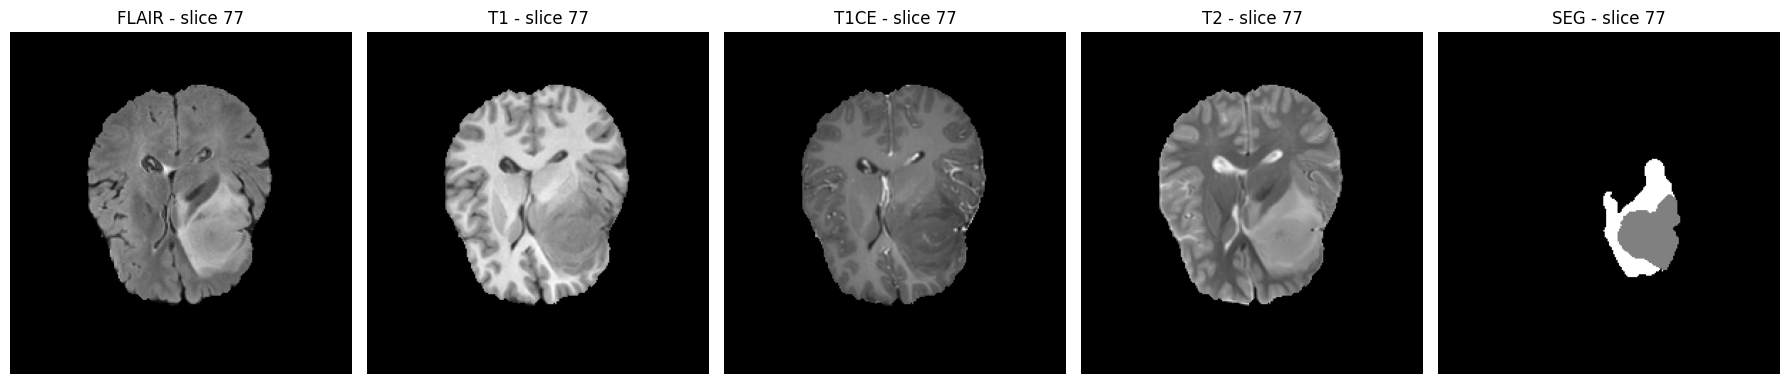

In [20]:
slice_idx = volumes["flair"].shape[2] // 2

modalities = ["flair", "t1", "t1ce", "t2", "seg"]

plt.figure(figsize=(18, 4))

for i, name in enumerate(modalities):
    plt.subplot(1, len(modalities), i + 1)
    plt.imshow(volumes[name][:, :, slice_idx].T, cmap="gray", origin="lower")
    plt.title(f"{name.upper()} - slice {slice_idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()